In [1]:
import requests
import json
import pandas as pd
import _utils_ as utils
import _connection_ as con

Variables

In [2]:
city = 'Bogota'
gbfs_url='https://bogota.publicbikesystem.net/customer/gbfs/v2/gbfs.json'

In [3]:
all_data_links = requests.get(gbfs_url).json()
feeds_dict = {feed['name']: feed['url'] for feed in all_data_links['data']['en']['feeds']}
all_data_links

{'last_updated': 1781110920,
 'ttl': 28,
 'data': {'en': {'feeds': [{'name': 'geofencing_zones',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/geofencing_zones'},
    {'name': 'gbfs_versions',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/gbfs_versions'},
    {'name': 'vehicle_types',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/vehicle_types'},
    {'name': 'station_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_information'},
    {'name': 'station_status',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/station_status'},
    {'name': 'system_regions',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_regions'},
    {'name': 'system_information',
     'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/en/system_information'},
    {'name': 'system_pricing_plans',
     'url': 'https://bogota.publicbikesystem.net/customer/

## 1 - Exploracion de Datos

### 1.1 Informacion general del sistema

In [4]:
geofencing_zones  = requests.get(feeds_dict['geofencing_zones']).json()
system_regions  = requests.get(feeds_dict['system_regions']).json()
system_information  = requests.get(feeds_dict['system_information']).json()
gbfs_versions = requests.get(feeds_dict['gbfs_versions']).json()
print("geofencing_zones\n", geofencing_zones['data'])
print("\nsystem_regions\n", system_regions['data'])
print("\nsystem_information\n", system_information['data'])
print("\ngbfs_versions\n",  gbfs_versions['data'])

geofencing_zones
 {'geofencing_zones': {'features': [], 'type': 'FeatureCollection'}}

system_regions
 {'regions': []}

system_information
 {'system_id': 'bogota_bike', 'timezone': 'America/Bogota', 'build_version': '2026.3', 'build_label': '2026-05-15', 'build_hash': 'bf9a38e', 'build_number': '1', 'mobile_head_version': '2', 'mobile_minimum_supported_version': '1', '_vehicle_count': {'_mechanical_count': 1942, '_ebike_count': 1556}, '_station_count': 196, 'language': 'en', 'name': 'bogota-bikebogota'}

gbfs_versions
 {'versions': [{'version': '1.1', 'url': 'https://bogota.publicbikesystem.net/ube/gbfs/v1/'}, {'version': '2.3', 'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v2/'}, {'version': '3.0', 'url': 'https://bogota.publicbikesystem.net/customer/gbfs/v3.0/'}]}


### 1.2. Precios de planes y tipos de vehiculos

In [5]:
# system_pricing_plans
system_pricing_plans = requests.get(feeds_dict['system_pricing_plans']).json()
for plan in system_pricing_plans['data']['plans'][0:5]:
    print(plan)


{'plan_id': '1', 'name': 'Teste 06.09', 'currency': 'COP', 'price': 9000.0, 'description': 'Teste 06.09', 'is_taxable': True, 'per_min_pricing': [{'start': 0, 'rate': 7500.0, 'interval': 30, 'end': 30}]}
{'plan_id': '2-2', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diario', 'is_taxable': True, 'per_min_pricing': [{'start': 65, 'rate': 150.0, 'interval': 1, 'end': 2465}]}
{'plan_id': '2-3', 'name': 'Diario', 'currency': 'COP', 'price': 11000.0, 'description': 'Diario', 'is_taxable': True, 'per_min_pricing': [{'start': 0, 'rate': 1999.0, 'interval': 1, 'end': 1}, {'start': 1, 'rate': 150.0, 'interval': 1, 'end': 2387}]}
{'plan_id': '3-5', 'name': '[Set.22] Mensual', 'currency': 'COP', 'price': 31990.0, 'description': '[Set.22] Mensual', 'is_taxable': True, 'per_min_pricing': [{'start': 60, 'rate': 150.0, 'interval': 1, 'end': 2460}]}
{'plan_id': '3-4', 'name': '[Set.22] Mensual', 'currency': 'COP', 'price': 31990.0, 'description': '[Set.22] Mensual', 'is_taxab

In [6]:
#vehicle_types
vehicle_types = requests.get(feeds_dict['vehicle_types']).json()
pd.DataFrame(vehicle_types['data']['vehicle_types']).head(7)

,vehicle_type_id,form_factor,propulsion_type,max_range_meters,name,default_pricing_plan_id,pricing_plan_ids
0,ICONIC,bicycle,human,0.0,ICONIC,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
1,FIT,bicycle,human,0.0,FIT,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
2,BOOST,bicycle,electric_assist,70000.0,BOOST,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
3,EFIT,bicycle,electric_assist,70000.0,EFIT,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."
4,MANOCLETA,other,human,0.0,MANOCLETA,3-5,"[3-5, 3-4, 8-9, 8-46, 11-12, 11-17, 12-2, 12-3..."
5,CAJON,bicycle,human,0.0,CAJON,3-5,"[3-5, 3-4, 8-9, 8-46, 11-12, 11-17, 12-2, 12-3..."
6,FIT CON SILLA,bicycle,human,0.0,FIT CON SILLA,1,"[1, 2-2, 2-3, 3-5, 3-4, 4-6, 4-7, 5, 6-9, 6-10..."


### 1.3 Informacion de Estacion

In [7]:
station_information = requests.get(feeds_dict['station_information']).json()
print("numero de estaciones: ", len(station_information['data']['stations']))
print(station_information['data']['stations'][0])
station_information_df = pd.DataFrame(station_information['data']['stations'][0:-1])
station_information_df[-4:-1]

numero de estaciones:  197
{'station_id': '1', 'external_id': 'eb1564d9-df87-11ef-b9d3-0681a956ccf1', 'name': '001 - CL 82 con KR 11', 'physical_configuration': 'REGULAR', 'lat': 4.6658027, 'lon': -74.0528436, 'altitude': None, 'address': 'Calle 82 entre Carrera 11 y Carrera 12', 'cross_street': 'EL RETIRO', 'post_code': '1111', 'capacity': 19, 'is_charging_station': False, 'geofenced_capacity': 0, 'rental_methods': ['key', 'transitcard', 'creditcard', 'phone'], 'is_virtual_station': False, 'groups': [], 'nearby_distance': 1000.0, '_bluetooth_id': '9d59', '_ride_code_support': True, 'rental_uris': {}}


,station_id,external_id,name,physical_configuration,lat,lon,altitude,address,cross_street,post_code,...,geofenced_capacity,rental_methods,is_virtual_station,groups,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,obcn,short_name
192,295,eb185908-df87-11ef-b9d3-0681a956ccf1,295 - AK 45 con CL 136,REGULAR,4.721452,-74.051005,0.0,Av. Carrera 45 entre Calle 136 y Calle 137,NaN,1111,...,0,"[key, transitcard, creditcard, phone]",False,[],1000.0,fa84,True,{},,
193,296,eb185b7e-df87-11ef-b9d3-0681a956ccf1,296 - KR 19A con CL 100,REGULAR,4.686673,-74.052952,NaN,Carrera 19A entre Calle 100 y Calle 101,NaN,1111,...,0,"[key, transitcard, creditcard, phone]",False,[],1000.0,2b00,True,{},,
194,298,eb185fd3-df87-11ef-b9d3-0681a956ccf1,298 - KR 23 con CL 104A,REGULAR,4.691679,-74.055155,NaN,Carrera 23 entre Calle 104A y Calle 104,NaN,1111,...,0,"[key, transitcard, creditcard, phone]",False,[],1000.0,090e,True,{},,


### 1.4 Estado de Estacion

In [8]:
station_status= requests.get(feeds_dict['station_status']).json()
print("numero de estaciones: ", len(station_status['data']['stations']))
print(list(station_status['data']['stations'][0].keys()))
print('vehicle_docks_available',station_status['data']['stations'][0]['vehicle_docks_available'])

print('vehicle_types_available')
for veh_type in station_status['data']['stations'][0]['vehicle_types_available']:
    print("  ",veh_type)
station_status_df = pd.DataFrame(station_status['data']['stations'])
station_status_df[0:4]

# station_status

numero de estaciones:  197
['station_id', 'num_bikes_available', 'num_bikes_disabled', 'is_charging_station', 'status', 'traffic', 'num_docks_available', 'num_docks_disabled', 'last_reported', 'is_installed', 'is_renting', 'is_returning', 'vehicle_docks_available', 'vehicle_types_available']
vehicle_docks_available [{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO', 'Handbike'], 'count': 1}]
vehicle_types_available
   {'vehicle_type_id': 'FIT', 'count': 17}
   {'vehicle_type_id': 'CARGO', 'count': 0}
   {'vehicle_type_id': 'Handbike', 'count': 0}
   {'vehicle_type_id': 'EFIT', 'count': 1}


,station_id,num_bikes_available,num_bikes_disabled,is_charging_station,status,traffic,num_docks_available,num_docks_disabled,last_reported,is_installed,is_renting,is_returning,vehicle_docks_available,vehicle_types_available
0,1,18,0,False,IN_SERVICE,None,1,0,1781110887,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 17}, {'ve..."
1,2,2,0,False,IN_SERVICE,None,5,0,1781110847,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 2}, {'veh..."
2,4,6,0,False,IN_SERVICE,None,5,0,1781110734,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 4}, {'veh..."
3,5,20,1,False,IN_SERVICE,None,19,0,1781110864,True,True,True,"[{'vehicle_type_ids': ['FIT', 'EFIT', 'CARGO',...","[{'vehicle_type_id': 'FIT', 'count': 20}, {'ve..."


## 2 - Visualizacion de Informacion

In [9]:
# station_information_df.sort_values(by=['lat', 'lon'], ascending=[True, True]).head(10)
#found an edge case with lat <0 when all other lats are ~4.6. Adding condition to filter out that station
station_information_df = station_information_df[station_information_df['lat'] > 0]

<Figure size 800x800 with 0 Axes>

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


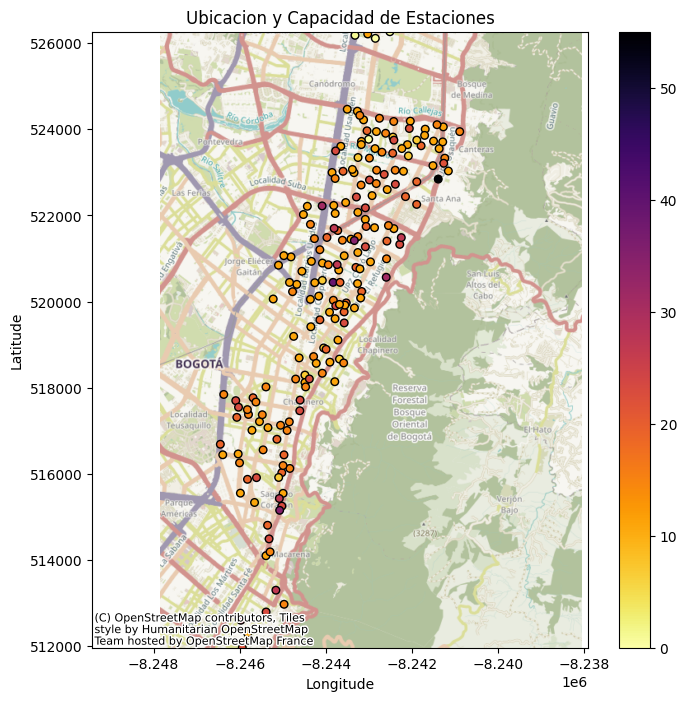

In [10]:
utils.plot_map(station_information_df, 'capacity', 'inferno_r', 'Ubicacion y Capacidad de Estaciones')

<Figure size 800x800 with 0 Axes>

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


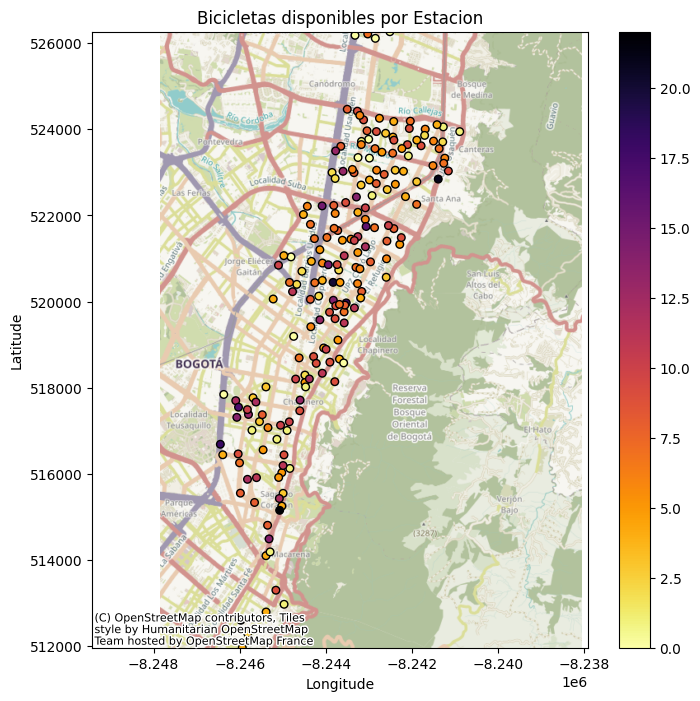

In [11]:
station_info_status_df = station_information_df.merge(station_status_df, on='station_id')
utils.plot_map(station_info_status_df, 'num_bikes_available', 'inferno_r', 'Bicicletas disponibles por Estacion')

<Figure size 800x800 with 0 Axes>

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


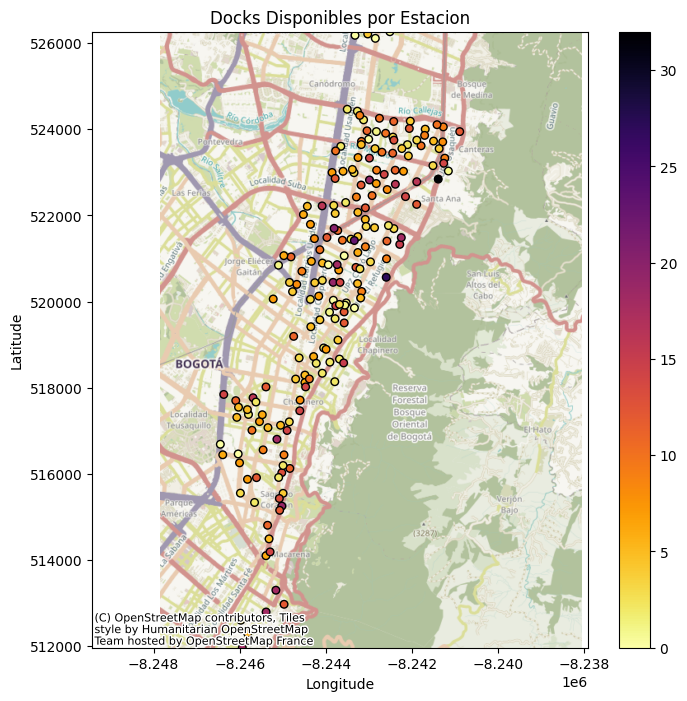

In [12]:
utils.plot_map(station_info_status_df, 'num_docks_available', 'inferno_r', 'Docks Disponibles por Estacion')

------- Seleccionar un subset de estaciones para alamacenamiento y analitica

In [57]:
station_info_df = station_information_df.sort_values(by="capacity", ascending=False)
station_info_df = utils.select_stations_far_apart(station_info_df, n=150, min_dist_m=800)


In [63]:
#### filtering and selecting stations by capacity, location, randomness


# 1. Select top N by capacity
top_capacity = station_info_df.nlargest(7, 'capacity')

# 2. Select stations with charging (if available)
charging_stations = station_info_df.drop(top_capacity.index).loc[station_info_df['is_charging_station'] == 1].sample(n=5, random_state=42)

# 3. Select geographical edges stations (e.g., by min/max lat)
geo_edges = station_info_df.loc[[
    station_info_df['lat'].idxmin(), station_info_df['lat'].idxmax(),
    station_info_df['lon'].idxmin(), station_info_df['lon'].idxmax()
]]

# 4. Add some random stations
remaining = station_info_df.drop(charging_stations.index).drop(geo_edges.index)
random_stations = remaining.sample(n=9, random_state=42)



In [64]:
# Combine and drop duplicates
selected_stations = pd.concat([top_capacity, charging_stations, geo_edges, random_stations]).drop_duplicates(subset=['station_id']).sort_values(by='station_id')

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


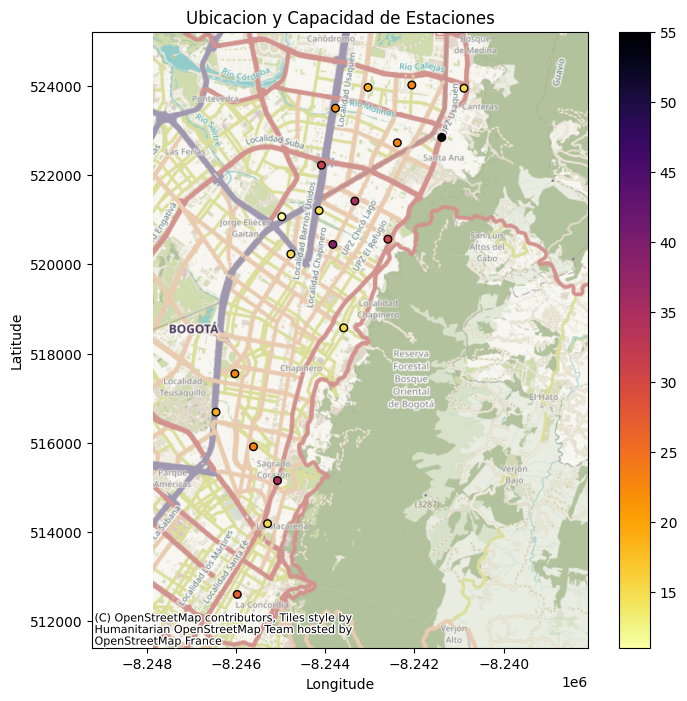

In [65]:
utils.plot_map(selected_stations, 'capacity', 'inferno_r', 'Ubicacion y Capacidad de Estaciones')

<Figure size 800x800 with 0 Axes>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


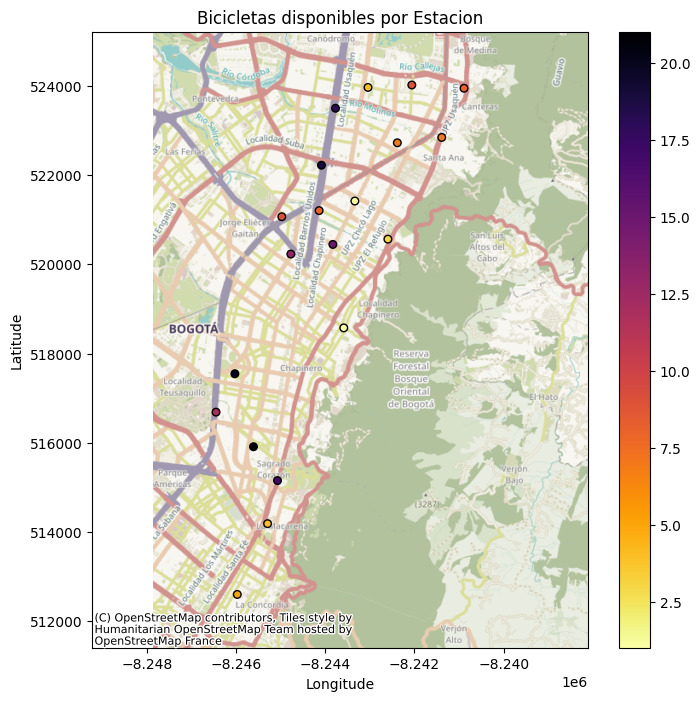

In [66]:
#Visualizar subsección de estaciones seleccionadas
station_info_status_sub_df = selected_stations.merge(station_status_df, on='station_id', how='left')
utils.plot_map(station_info_status_sub_df, 'num_bikes_available', 'inferno_r', 'Bicicletas disponibles por Estacion')

In [8]:
## save the selected stations to a csv file in the static_data_files folder
from datetime import datetime
today = datetime.now().strftime("%Y-%m-%d")
# selected_stations.to_csv(f'static_data_files/selected_stations_{today}.csv', index=False)
station_information_df.to_csv(f'static_data_files/station_info_all_{today}.csv', index=False)